<a href="https://colab.research.google.com/github/Gobihanath/BikeRent/blob/main/Concrete_compression_strength_prediction_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#csv upload
from google.colab import files
uploaded = files.upload()

Saving Concrete Compressive Strength.csv to Concrete Compressive Strength.csv


In [ ]:
!pip install tensorflow

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn  # Import sklearn after installing the specific version
sklearn.set_config(display='text')
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

import tensorflow as tf


In [ ]:
# from google.colab import drive
# drive.mount('/content/gdrive')

# !ln -s /content/gdrive/My\ Drive/ /mydrive
# !ls /mydrive

In [ ]:
# %cd /content/gdrive/MyDrive/Dataset

In [4]:
df = pd.read_csv('Concrete Compressive Strength.csv')

In [ ]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Cement                          1030 non-null   float64
 1   Blast Furnace Slag              1030 non-null   float64
 2   Fly Ash                         1030 non-null   float64
 3   Water                           1030 non-null   float64
 4   Superplasticizer                1030 non-null   float64
 5   Coarse Aggregate                1030 non-null   float64
 6   Fine Aggregate                  1030 non-null   float64
 7   Age (day)                       1030 non-null   int64  
 8   Concrete compressive strength   1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [ ]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [ ]:
# missing_vals=df.isnull().sum()
# missing_vals

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age (day),0
Concrete compressive strength,0


In [ ]:
df.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age (day)',
       'Concrete compressive strength '],
      dtype='object')

In [ ]:
df.corr()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
Cement,1.000000,-0.275193,-0.397475,-0.081544,0.092771,-0.109356,-0.222720,0.081947,0.497833
Blast Furnace Slag,-0.275193,1.000000,-0.323569,0.107286,0.043376,-0.283998,-0.281593,-0.044246,0.134824
Fly Ash,-0.397475,-0.323569,1.000000,-0.257044,0.377340,-0.009977,0.079076,-0.154370,-0.105753
Water,-0.081544,0.107286,-0.257044,1.000000,-0.657464,-0.182312,-0.450635,0.277604,-0.289613
Superplasticizer,0.092771,0.043376,0.377340,-0.657464,1.000000,-0.266303,0.222501,-0.192717,0.366102
Coarse Aggregate,-0.109356,-0.283998,-0.009977,-0.182312,-0.266303,1.000000,-0.178506,-0.003016,-0.164928
Fine Aggregate,-0.222720,-0.281593,0.079076,-0.450635,0.222501,-0.178506,1.000000,-0.156094,-0.167249
Age (day),0.081947,-0.044246,-0.154370,0.277604,-0.192717,-0.003016,-0.156094,1.000000,0.328877
Concrete compressive strength,0.497833,0.134824,-0.105753,-0.289613,0.366102,-0.164928,-0.167249,0.328877,1.000000


###XGBoost

In [ ]:
# Split features and target
X = df.drop('Concrete compressive strength ', axis=1)
y = df['Concrete compressive strength ']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# XGBoost Regressor
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predict on test set
test_pred = model.predict(X_test)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, test_pred))
mae = mean_absolute_error(y_test, test_pred)
r2 = r2_score(y_test, test_pred)

print("XGBoost Regressor Model: Test Data")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}\n")



XGBoost Regressor Model: Test Data
RMSE: 4.5470
MAE: 3.0058
R² Score: 0.9198



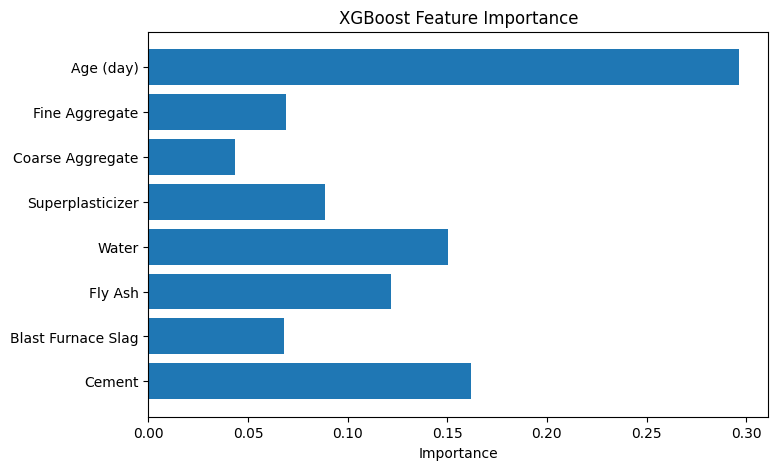

In [ ]:
# ----------------------------
# Feature importance plot
# ----------------------------
plt.figure(figsize=(8,5))
plt.barh(X.columns, model.feature_importances_)
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.show()

### Randomforest

In [ ]:
# Split features and target
X = df.drop('Concrete compressive strength ', axis=1)
y = df['Concrete compressive strength ']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest Regressor
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predict on test set
test_pred = model.predict(X_test)





In [ ]:
# ----------------------------
# Evaluation (formatted output)
# ----------------------------
rmse = np.sqrt(mean_squared_error(y_test, test_pred))
mae = mean_absolute_error(y_test, test_pred)
r2 = r2_score(y_test, test_pred)

print("Random Forest Regressor Model: Test Data")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}\n")

Random Forest Regressor Model: Test Data
RMSE: 5.5746
MAE: 3.8119
R² Score: 0.8794



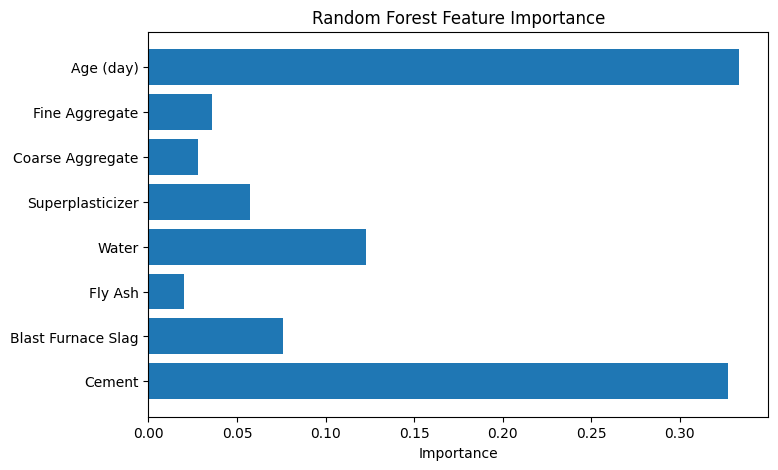

In [ ]:
# ----------------------------
# Feature importance plot
# ----------------------------
plt.figure(figsize=(8,5))
plt.barh(X.columns, model.feature_importances_)
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

### CNN

In [ ]:
# Split features and target
X = df.drop('Concrete compressive strength ', axis=1).values
y = df['Concrete compressive strength '].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for CNN (samples, timesteps, features)
# Here each feature = 1 timestep
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# --------------------------------------
# Build the 1D CNN model
# --------------------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.Conv1D(32, kernel_size=2, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Predict
test_pred = model.predict(X_test).flatten()

# --------------------------------------
# Evaluation (formatted output)
# --------------------------------------
rmse = np.sqrt(mean_squared_error(y_test, test_pred))
mae = mean_absolute_error(y_test, test_pred)
r2 = r2_score(y_test, test_pred)

print("CNN Regressor Model: Test Data")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}\n")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 1548.1285 - mae: 35.3295 - val_loss: 1279.7683 - val_mae: 32.3875
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1060.1361 - mae: 27.3631 - val_loss: 324.5599 - val_mae: 14.0133
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 302.3342 - mae: 13.7535 - val_loss: 267.8599 - val_mae: 12.7436
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 300.0367 - mae: 13.7880 - val_loss: 255.1471 - val_mae: 12.5260
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 279.7123 - mae: 13.4847 - val_loss: 258.2562 - val_mae: 12.5281
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 271.5010 - mae: 13.3590 - val_loss: 242.3047 - val_mae: 12.4322
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 260.5271 - mae: 13.2434 - val_loss: 241.7597 - val_mae: 12.1512
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 247.7981 - mae: 12.6975 - val_loss: 234.8725 - val_mae: 12.0209
Epoch 9/50
24/

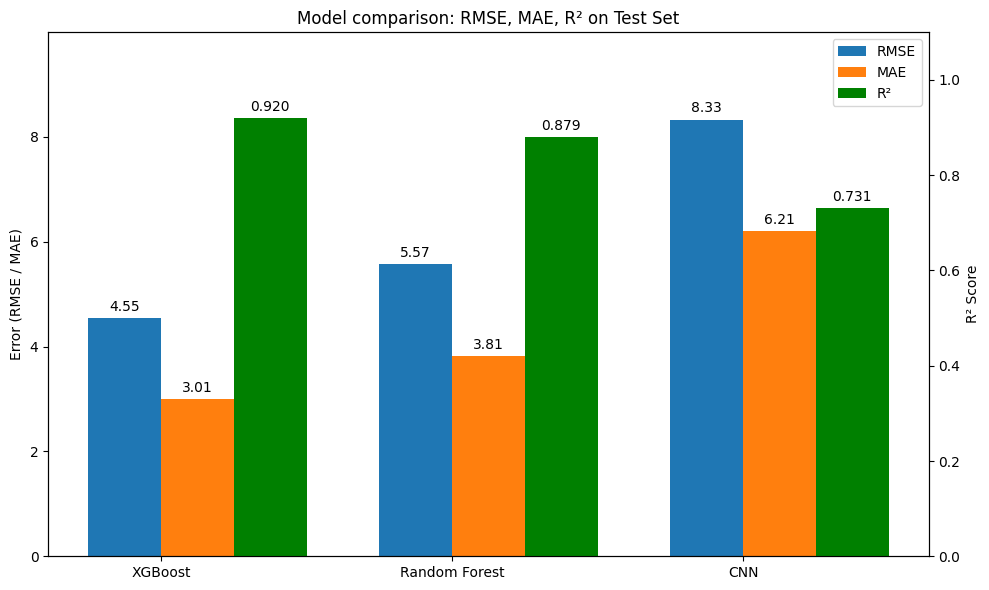

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Results from your runs
models = ['XGBoost', 'Random Forest', 'CNN']
rmse  = [4.5470, 5.5746, 8.3298]
mae   = [3.0058, 3.8119, 6.2108]
r2    = [0.9198, 0.8794, 0.7307]

x = np.arange(len(models))  # the label locations
width = 0.25  # the width of the bars

fig, ax1 = plt.subplots(figsize=(10,6))

# RMSE and MAE bars on primary y-axis
rects1 = ax1.bar(x - width/2, rmse, width, label='RMSE')
rects2 = ax1.bar(x + width/2, mae, width, label='MAE')
ax1.set_ylabel('Error (RMSE / MAE)')
ax1.set_ylim(0, max(rmse + mae) * 1.2)

# Create a second y-axis for R²
ax2 = ax1.twinx()
rects3 = ax2.bar(x + width*1.5, r2, width, label='R²', color='green')
ax2.set_ylabel('R² Score')
ax2.set_ylim(0, 1.1)

# X-axis tick labels
ax1.set_xticks(x)
ax1.set_xticklabels(models)

# Legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

# Add value labels on bars
def add_labels(rects, axis, fmt='%.2f'):
    for rect in rects:
        height = rect.get_height()
        axis.annotate(fmt % height,
                      xy=(rect.get_x() + rect.get_width() / 2, height),
                      xytext=(0, 3),
                      textcoords="offset points",
                      ha='center', va='bottom')

add_labels(rects1, ax1)
add_labels(rects2, ax1)
add_labels(rects3, ax2, fmt='%.3f')

plt.title('Model comparison: RMSE, MAE, R² on Test Set')
plt.tight_layout()
plt.show()


### SVM

In [ ]:
# Split features and target
X = df.drop('Concrete compressive strength ', axis=1)
y = df['Concrete compressive strength ']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# Scaling (VERY IMPORTANT for SVM)
# ---------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------
# SVM Regressor (SVR)
# ---------------------------
model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)

# Train
model.fit(X_train, y_train)

# Predict
test_pred = model.predict(X_test)

# ---------------------------
# Evaluation
# ---------------------------
rmse = np.sqrt(mean_squared_error(y_test, test_pred))
mae = mean_absolute_error(y_test, test_pred)
r2 = r2_score(y_test, test_pred)

print("SVM Regressor (SVR) Model: Test Data")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}\n")

SVM Regressor (SVR) Model: Test Data
RMSE: 5.7297
MAE: 3.9869
R² Score: 0.8726



### Decision Tre

Decision Tree Regressor Model: Test Data
RMSE: 6.9772
MAE: 4.4615
R² Score: 0.8111



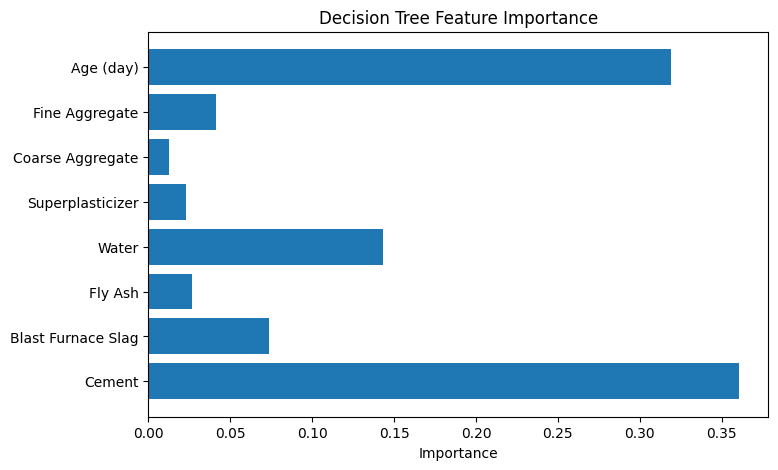

In [ ]:
X = df.drop('Concrete compressive strength ', axis=1)
y = df['Concrete compressive strength ']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --------------------------------------
# Decision Tree Regressor
# --------------------------------------
model = DecisionTreeRegressor(
    max_depth=None,       # You can tune this
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
test_pred = model.predict(X_test)

# --------------------------------------
# Evaluation
# --------------------------------------
rmse = np.sqrt(mean_squared_error(y_test, test_pred))
mae = mean_absolute_error(y_test, test_pred)
r2 = r2_score(y_test, test_pred)

print("Decision Tree Regressor Model: Test Data")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}\n")

# --------------------------------------
# Feature Importance Plot
# --------------------------------------
plt.figure(figsize=(8,5))
plt.barh(X.columns, model.feature_importances_)
plt.xlabel("Importance")
plt.title("Decision Tree Feature Importance")
plt.show()

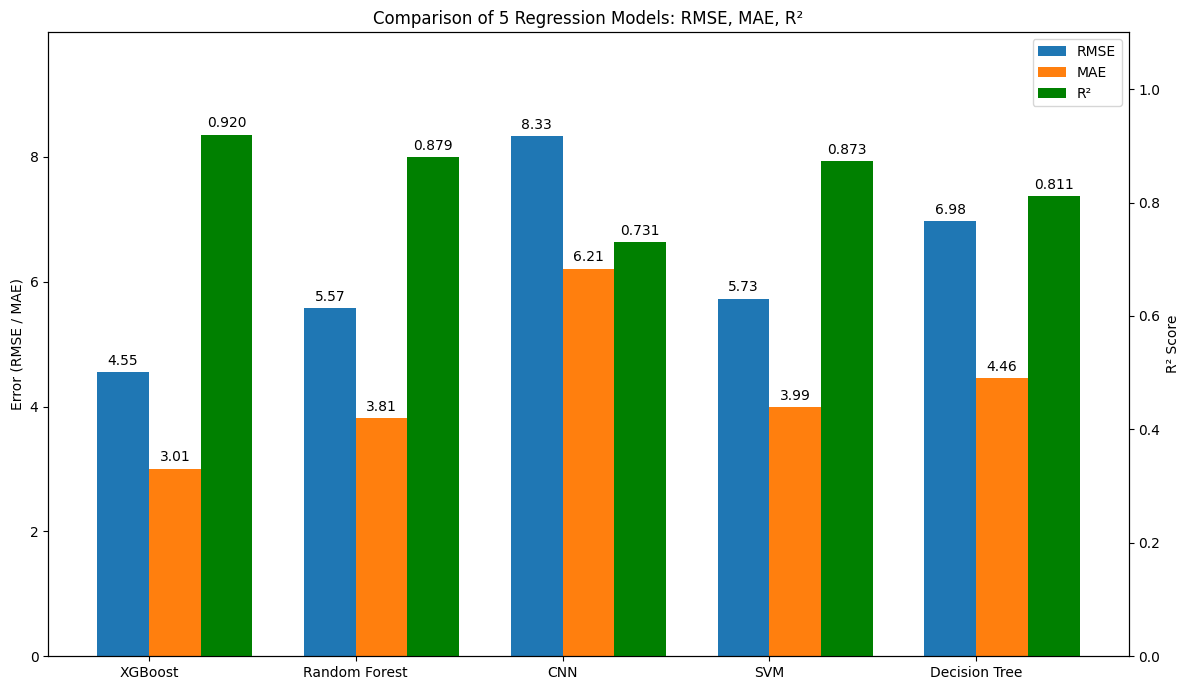

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Results from your runs
models = ['XGBoost', 'Random Forest', 'CNN', 'SVM', 'Decision Tree']

rmse  = [4.5470, 5.5746, 8.3298, 5.7297, 6.9772]
mae   = [3.0058, 3.8119, 6.2108, 3.9869, 4.4615]
r2    = [0.9198, 0.8794, 0.7307, 0.8726, 0.8111]

x = np.arange(len(models))  # label locations
width = 0.25  # width of the bars

fig, ax1 = plt.subplots(figsize=(12,7))

# RMSE and MAE bars (left axis)
rects1 = ax1.bar(x - width/2, rmse, width, label='RMSE')
rects2 = ax1.bar(x + width/2, mae, width, label='MAE')
ax1.set_ylabel('Error (RMSE / MAE)')
ax1.set_ylim(0, max(rmse + mae) * 1.2)

# R² bars (right axis)
ax2 = ax1.twinx()
rects3 = ax2.bar(x + width*1.5, r2, width, label='R²', color='green')
ax2.set_ylabel('R² Score')
ax2.set_ylim(0, 1.1)

# X-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels(models)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Value labels
def add_labels(rects, axis, fmt='%.2f'):
    for rect in rects:
        height = rect.get_height()
        axis.annotate(fmt % height,
                      xy=(rect.get_x() + rect.get_width() / 2, height),
                      xytext=(0, 3),
                      textcoords="offset points",
                      ha='center', va='bottom')

add_labels(rects1, ax1)
add_labels(rects2, ax1)
add_labels(rects3, ax2, fmt='%.3f')

plt.title('Comparison of 5 Regression Models: RMSE, MAE, R²')
plt.tight_layout()
plt.show()


## EBM

In [5]:
pip install interpret


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 59.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 115.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.6 MB/s eta 0:00:00
  Created wheel for dash-cytoscape: filename=dash_cytoscape-1.0.2-py3-none-any.whl size=4

In [6]:
from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show

EBM Regressor Model: Test Data
RMSE: 4.2158
MAE: 2.9842
R² Score: 0.9310



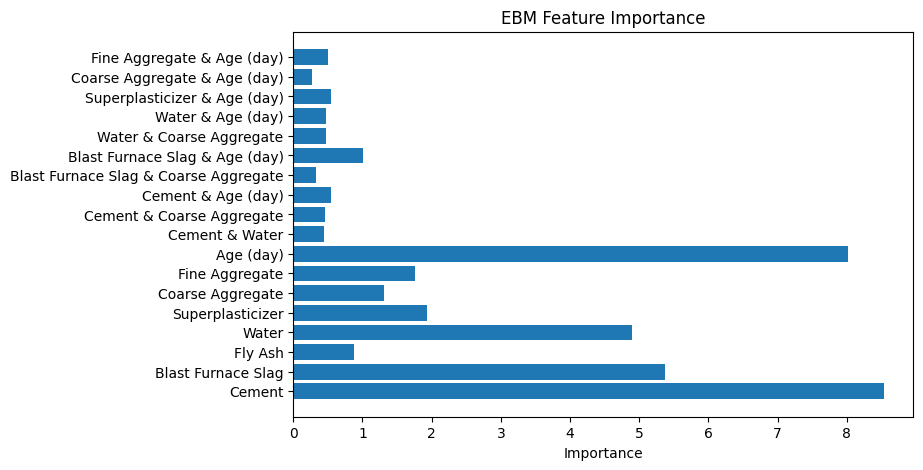

In [7]:
X = df.drop('Concrete compressive strength ', axis=1)
y = df['Concrete compressive strength ']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------
# EBM Model
# ------------------------------
ebm = ExplainableBoostingRegressor(
    random_state=42,
    max_bins=256,
    interactions=10        # Increase if you want more interaction terms
)

# Train
ebm.fit(X_train, y_train)

# Predict
test_pred = ebm.predict(X_test)

# ------------------------------
# Evaluation
# ------------------------------
rmse = np.sqrt(mean_squared_error(y_test, test_pred))
mae = mean_absolute_error(y_test, test_pred)
r2 = r2_score(y_test, test_pred)

print("EBM Regressor Model: Test Data")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}\n")

# ------------------------------
# Feature Importance (Global)
# ------------------------------
global_exp = ebm.explain_global()
show(global_exp)

# Optional: Plot only numeric importance
importances = global_exp.data()['scores']
features = global_exp.data()['names']

plt.figure(figsize=(8, 5))
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("EBM Feature Importance")
plt.show()

## GAM - Generalized additive model

In [8]:
!pip install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.6 MB/s eta 0:00:00


GAM (Generalized Additive Model) Regressor: Test Data
RMSE: 5.6258
MAE: 4.5105
R² Score: 0.8772



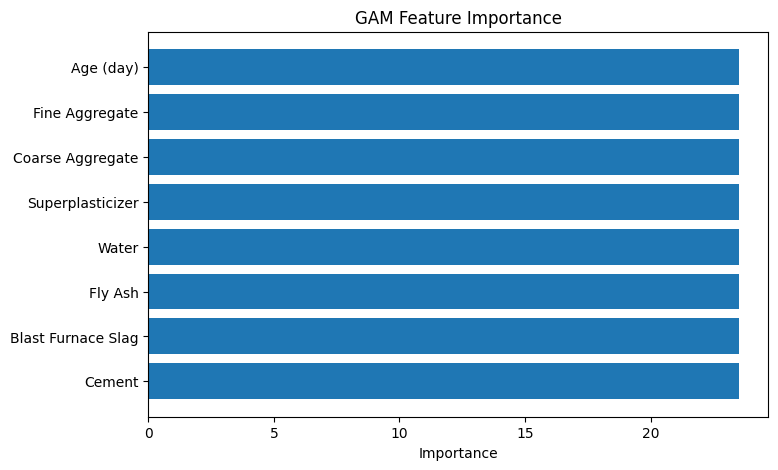

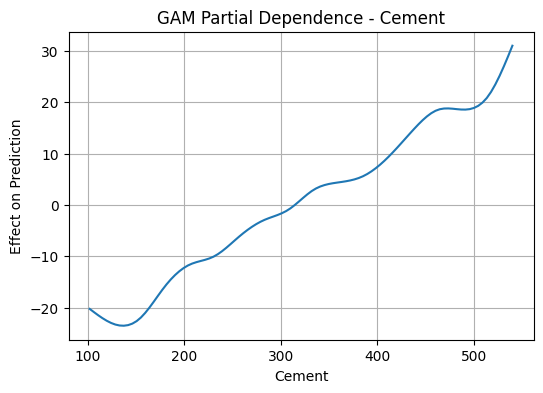

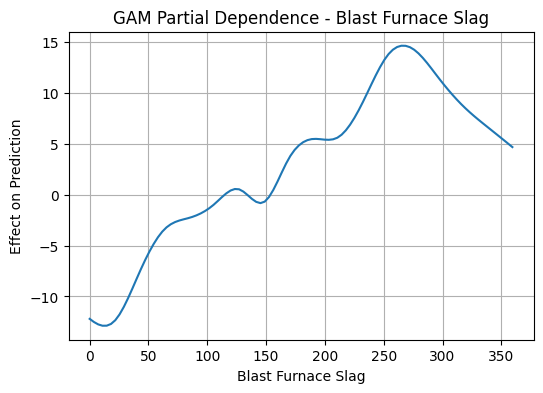

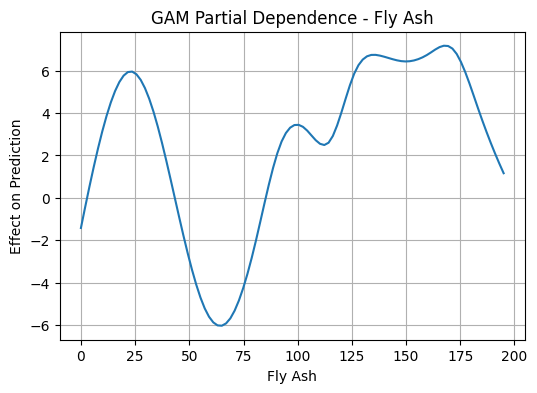

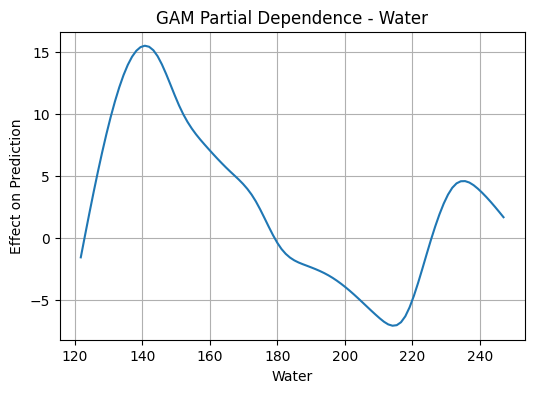

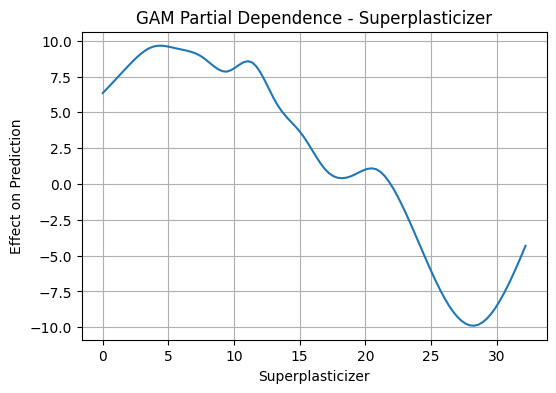

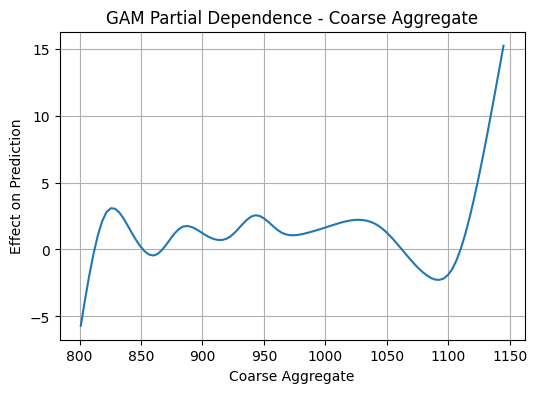

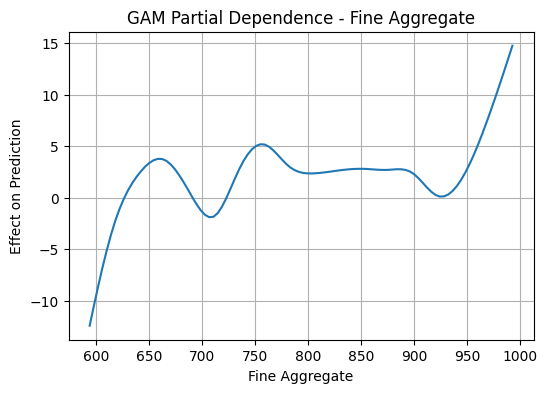

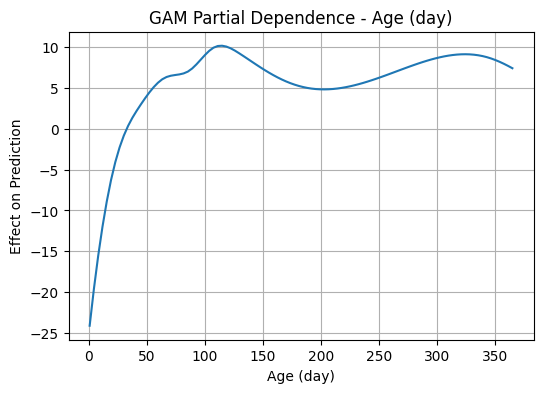

In [9]:
from pygam import LinearGAM, s
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --------------------------------------
# Prepare Data
# --------------------------------------
X = df.drop('Concrete compressive strength ', axis=1)
y = df['Concrete compressive strength ']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --------------------------------------
# Train GAM Model
# --------------------------------------

# Create a GAM with smooth terms for each feature
gam = LinearGAM(n_splines=20).fit(X_train, y_train)

# --------------------------------------
# Predict
# --------------------------------------
test_pred = gam.predict(X_test)

# --------------------------------------
# Evaluation Metrics
# --------------------------------------
rmse = np.sqrt(mean_squared_error(y_test, test_pred))
mae = mean_absolute_error(y_test, test_pred)
r2 = r2_score(y_test, test_pred)

print("GAM (Generalized Additive Model) Regressor: Test Data")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}\n")

# --------------------------------------
# Feature Importance (Based on Deviance Reduction)
# --------------------------------------
importance = gam.deviance_residuals(X_train, y_train).var(axis=0)

plt.figure(figsize=(8,5))
plt.barh(X.columns, importance)
plt.xlabel("Importance")
plt.title("GAM Feature Importance")
plt.show()

# --------------------------------------
# Partial Dependence Plots for each feature
# --------------------------------------
for i, col in enumerate(X.columns):
    plt.figure(figsize=(6,4))
    XX = gam.generate_X_grid(term=i)
    plt.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    plt.title(f"GAM Partial Dependence - {col}")
    plt.xlabel(col)
    plt.ylabel("Effect on Prediction")
    plt.grid(True)
    plt.show()
